In [1]:
# Imports

from keras.datasets import cifar10, mnist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import set_random_seed, to_categorical
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

set_random_seed(1024) # Set a global seed to grant reproducibility

I0000 00:00:1776728450.242593   46243 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776728450.285388   46243 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776728451.349807   46243 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Carregamento dos datasets

Aqui a gente vai explicar que vamos utilizar o mnist e o CIFAR 10, dizer sobre o que cada um deles se trata

In [2]:
# Loading mnist dataset

# Loading CIFAR-10 dataset

(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()


cifar_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
mnist_class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

print('Cifar-10 train images shape:\t\t', cifar_x_train.shape)
print('Cifar-10 train labels shape:\t\t', cifar_y_train.shape)
print('Mnist train images shape:\t\t', mnist_x_train.shape)
print('Mnist train labels shape:\t\t', mnist_y_train.shape)

print('\nCifar-10 test images shape:\t\t', cifar_x_test.shape)
print('Cifar-10 test labels shape:\t\t', cifar_y_test.shape)
print('Mnist test images shape:\t\t', mnist_x_test.shape)
print('Mnist test labels shape:\t\t', mnist_y_test.shape)

/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Cifar-10 train images shape:		 (50000, 32, 32, 3)
Cifar-10 train labels shape:		 (50000, 1)
Mnist train images shape:		 (60000, 28, 28)
Mnist train labels shape:		 (60000,)

Cifar-10 test images shape:		 (10000, 32, 32, 3)
Cifar-10 test labels shape:		 (10000, 1)
Mnist test images shape:		 (10000, 28, 28)
Mnist test labels shape:		 (10000,)


# Visualização dos dados

Segue abaixo uma visualização das primeiras imagens de ambos os datasets:

In [3]:
def show_images_samples(dataset_name,x_train, y_train, x_test, y_test, class_names, n_samples=8, cmap=None):
    """
    Show some samples of the dataset.
    """
    figure, axes = plt.subplots(2, n_samples, figsize=(15, 6))

    figure.suptitle(f'{dataset_name} - Image Samples', fontsize=16)
    figure.text(0.5, 0.88, 'Training', fontsize=16, ha='center')    
    figure.text(0.5, 0.47, 'Test', fontsize=16, ha='center')    

    for i in range(n_samples):
        train_label = int(np.squeeze(y_train[i]))
        test_label = int(np.squeeze(y_test[i]))

        # Show training samples
        axes[0, i].imshow(x_train[i], cmap=cmap)
        axes[0, i].set_title(f'{class_names[train_label]}')
        axes[0, i].axis('off')
        
        # Show test samples
        axes[1, i].imshow(x_test[i], cmap=cmap)
        axes[1, i].set_title(f'{class_names[test_label]}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

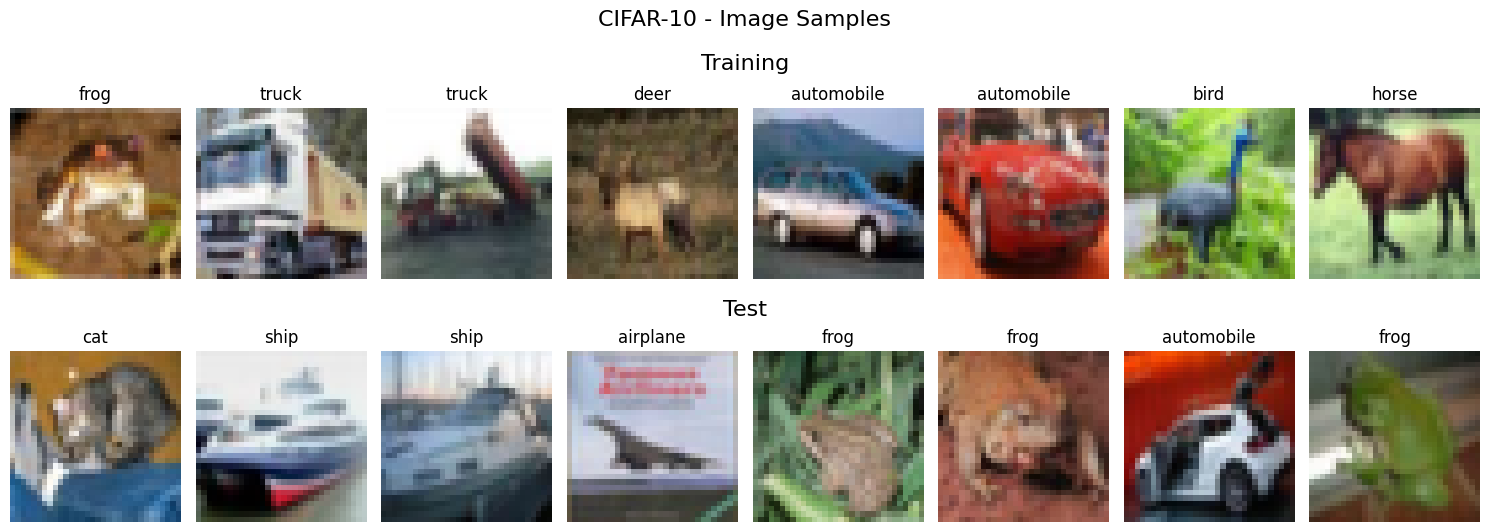

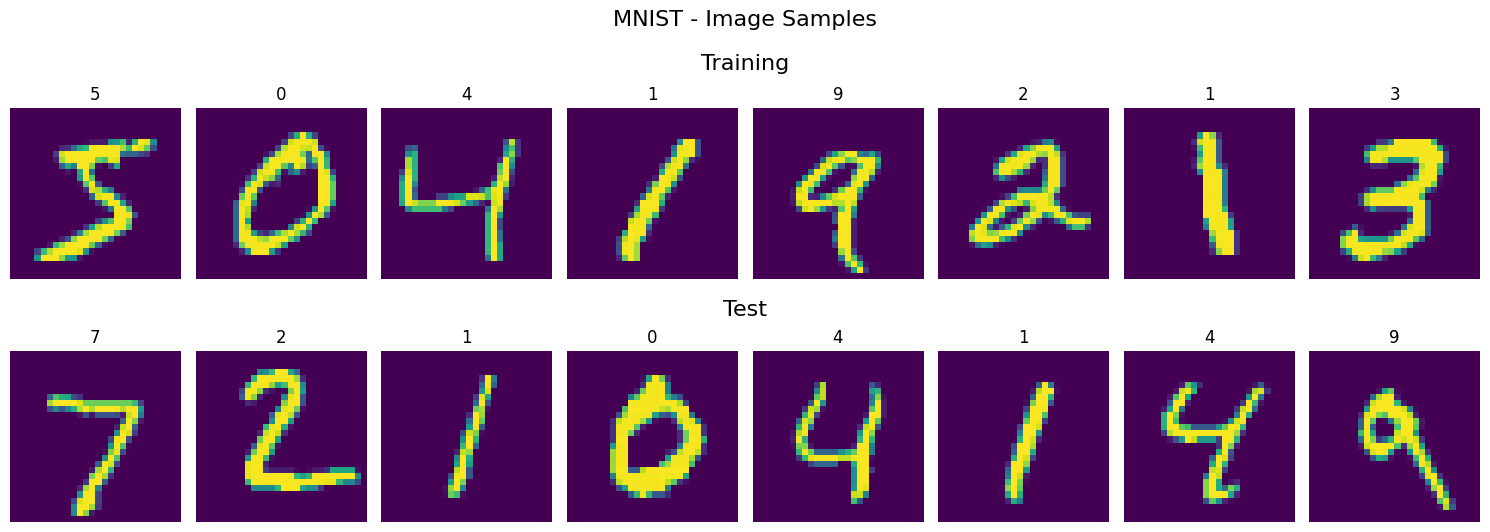

In [4]:
show_images_samples(
    "CIFAR-10",
    cifar_x_train, 
    cifar_y_train, 
    cifar_x_test, 
    cifar_y_test, 
    cifar_class_names
)

show_images_samples(
    "MNIST",
    mnist_x_train, 
    mnist_y_train, 
    mnist_x_test, 
    mnist_y_test, 
    mnist_class_names
)

# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento sobre o sataset do *CIFAR-10*:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [5]:
def convert_to_grayscale(x_train, x_test):
    """
    Convert the images from RGB to grayscale using the standard formula: Y = 0.299 R + 0.587 G + 0.114 B
    """
    x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
    x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])
    
    return x_train_gray, x_test_gray

In [6]:
# Convert the images from RGB to grayscale

# standard formula: Y = 0.299 R + 0.587 G + 0.114 B
cifar_x_train_gray, cifar_x_test_gray = convert_to_grayscale(cifar_x_train, cifar_x_test)

print('CIFAR-10 train images shape (Gray scale):      ', cifar_x_train_gray.shape)
print('CIFAR-10 test images shape (Gray scale):       ', cifar_x_test_gray.shape)
print('MNIST train images shape (Gray scale):         ', mnist_x_train.shape)
print('MNIST test images shape (Gray scale):          ', mnist_x_test.shape)

CIFAR-10 train images shape (Gray scale):       (50000, 32, 32)
CIFAR-10 test images shape (Gray scale):        (10000, 32, 32)
MNIST train images shape (Gray scale):          (60000, 28, 28)
MNIST test images shape (Gray scale):           (10000, 28, 28)


In [7]:
def flatten_and_normalize_images(x_train, x_test):
    """
    Flatten the images and normalize to [0, 1] (improves stability and accuracy).
    """
    x_train_flat = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.0
    x_test_flat = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.0

    return pd.DataFrame(x_train_flat), pd.DataFrame(x_test_flat)

def convert_label_to_one_hot(y_train, y_test, num_classes=10):
    """
    Convert the labels to one-hot encoding.
    """
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)

    return pd.DataFrame(y_train_one_hot), pd.DataFrame(y_test_one_hot)

In [8]:
# Flatten the images and normalize to [0, 1] (improves stability and accuracy)

cifar_x_train_gray_flat_df, cifar_x_test_gray_flat_df = flatten_and_normalize_images(cifar_x_train_gray, cifar_x_test_gray)
mnist_x_train_gray_flat_df, mnist_x_test_gray_flat_df = flatten_and_normalize_images(mnist_x_train, mnist_x_test)

print('CIFAR-10 train images shape (Gray scale & Flatten):\t\t', cifar_x_train_gray_flat_df.shape)
print('CIFAR-10 test images shape (Gray scale & Flatten):\t\t', cifar_x_test_gray_flat_df.shape)
print('MNIST train images shape (Gray scale & Flatten):\t\t', mnist_x_train_gray_flat_df.shape)
print('MNIST test images shape (Gray scale & Flatten):\t\t\t', mnist_x_test_gray_flat_df.shape)

# Convert the labels to one-hot encoding

cifar_y_train_cat_df, cifar_y_test_cat_df = convert_label_to_one_hot(cifar_y_train, cifar_y_test)
mnist_y_train_cat_df, mnist_y_test_cat_df = convert_label_to_one_hot(mnist_y_train, mnist_y_test)

print('\nCIFAR-10 train labels shape (One-hot):\t\t\t\t', cifar_y_train_cat_df.shape)
print('CIFAR-10 test labels shape (One-hot):\t\t\t\t', cifar_y_test_cat_df.shape)
print('MNIST train labels shape (One-hot):\t\t\t\t', mnist_y_train_cat_df.shape)
print('MNIST test labels shape (One-hot):\t\t\t\t', mnist_y_test_cat_df.shape)

CIFAR-10 train images shape (Gray scale & Flatten):		 (50000, 1024)
CIFAR-10 test images shape (Gray scale & Flatten):		 (10000, 1024)
MNIST train images shape (Gray scale & Flatten):		 (60000, 784)
MNIST test images shape (Gray scale & Flatten):			 (10000, 784)

CIFAR-10 train labels shape (One-hot):				 (50000, 10)
CIFAR-10 test labels shape (One-hot):				 (10000, 10)
MNIST train labels shape (One-hot):				 (60000, 10)
MNIST test labels shape (One-hot):				 (10000, 10)


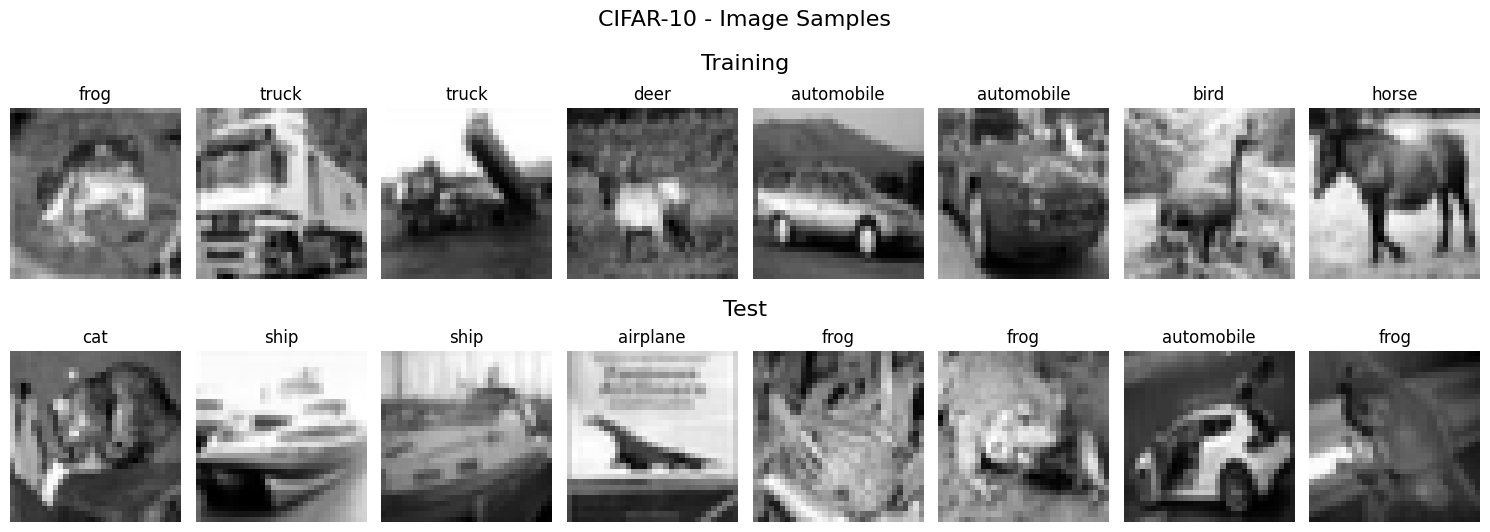

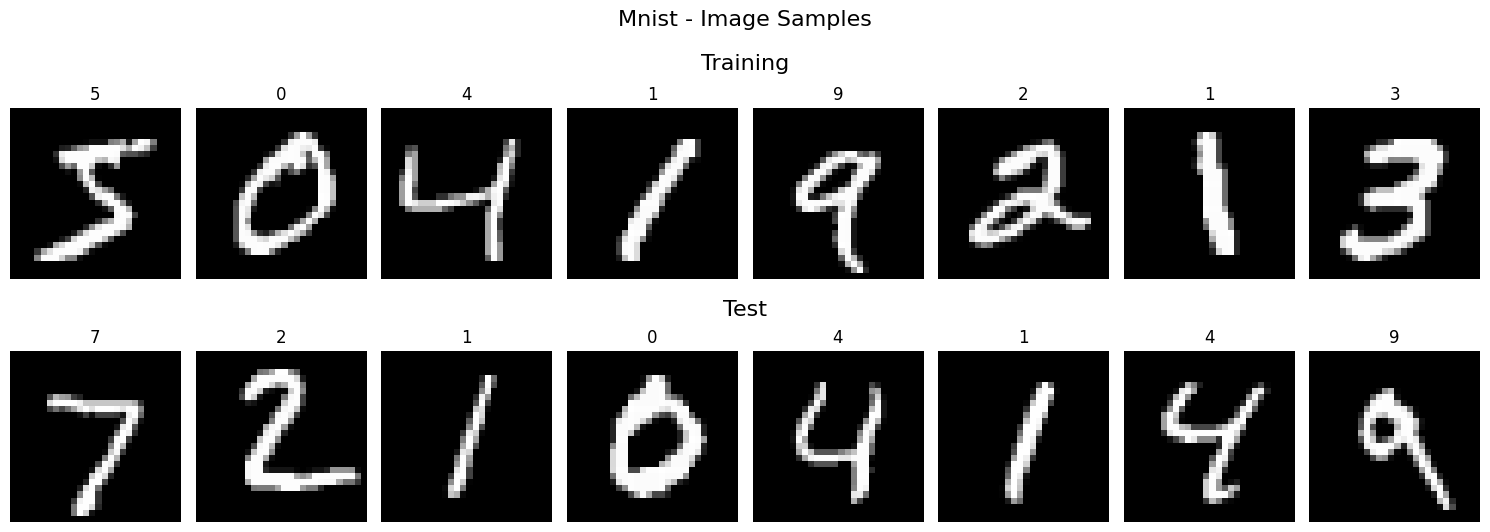

In [9]:
show_images_samples(
    "CIFAR-10",
    cifar_x_train_gray_flat_df.to_numpy().reshape(-1, 32, 32),
    cifar_y_train, 
    cifar_x_test_gray_flat_df.to_numpy().reshape(-1, 32, 32), 
    cifar_y_test, 
    cifar_class_names, 
    cmap='gray'
)

show_images_samples(
    "Mnist",
    mnist_x_train_gray_flat_df.to_numpy().reshape(-1, 28, 28),
    mnist_y_train, 
    mnist_x_test_gray_flat_df.to_numpy().reshape(-1, 28, 28), 
    mnist_y_test, 
    mnist_class_names, 
    cmap='gray'
)

# Estrutura da rede

In [10]:
# Hiper-parâmetros

cifar_input_shape = 1024            # 32 x 32 x 1
mnist_input_shape = 784             # 28 x 28 x 1
epochs = 50                         # https://keras.io/examples/vision/mlp_image_classification/
batch_size = 128                    # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
dropout_rate = 0.2                  # https://keras.io/examples/vision/mlp_image_classification/
learning_rate = 0.001               # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
early_stopping_patience = 5       # https://keras.io/api/callbacks/early_stopping/

#Outras Fontes
#https://pvss.github.io/MLP+of+CIFAR-10
#https://www.kaggle.com/code/yorkyong/exploring-cifar-10-w-mlp-cnn-resnet

In [11]:
# MLP model construction

# Structure based on the article
# "UTILIZAÇÃO DE REDES NEURAIS ARTIFICIAIS PARA A CLASSIFICAÇÃO DECORROSÃO POR PITE OBSERVADAS EM IMAGENS OBTIDAS COM O ENSAIO NÃO INVASIVO DE QUEDA DE POTENCIAL"
# by GABRIEL PEREIRA HOLANDA BARRETO (https://repositorio.ufc.br/bitstream/riufc/83115/1/2025_tcc_gphbarreto.pdf)

def create_mlp_model(dataset_name, dropout_rate=None):
    input_shape = cifar_input_shape if "CIFAR-10" in dataset_name else mnist_input_shape

    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def train_model(model, x_train, y_train, epochs=epochs, batch_size=batch_size, early_stopping=False, patience=None):
    callbacks = []

    if early_stopping:
        callbacks.append(
            EarlyStopping(
                monitor='val_loss', 
                patience=patience, 
                restore_best_weights=True
            )
        )

    history = model.fit(
        x_train, y_train,
        validation_split=0.1,  # Use 10% of the training data for validation
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    return history

def show_experiment_results(history, dataset_name=""):
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ---------------------------
    # Accuracy
    # ---------------------------
    axes[0].plot(
        history.history['accuracy'],
        '--',
        label='Train'
    )

    axes[0].plot(
        history.history['val_accuracy'],
        '-',
        label='Validation'
    )

    axes[0].set_title(f'{dataset_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # ---------------------------
    # Loss
    # ---------------------------
    axes[1].plot(
        history.history['loss'],
        '--',
        label='Train'
    )

    axes[1].plot(
        history.history['val_loss'],
        '-',
        label='Validation'
    )

    axes[1].set_title(f'{dataset_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # ---------------------------
    # Final metrics
    # ---------------------------
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    generalization_gap = val_loss - train_loss

    print(f'  Train loss      : {train_loss:.4f}')
    print(f'  Validation loss : {val_loss:.4f}')
    print(f'  Train accuracy  : {train_acc:.4f}')
    print(f'  Validation acc  : {val_acc:.4f}')
    print(f'  Generalization gap (val - train loss): {generalization_gap:.4f}')
    

def run_experiment(dataset_name, x_train, y_train, x_test, y_test, dropout_rate=0, early_stopping=False, patience=None):
    model = create_mlp_model(dataset_name, dropout_rate)
    history = train_model(model, x_train, y_train, epochs=epochs, batch_size=batch_size, early_stopping=early_stopping, patience=patience)

    show_experiment_results(history, dataset_name)

    train_acc = history.history['accuracy'][-1] 

    loss, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    return train_acc, acc, loss

# Experimento 1 - Sem dropout e sem early stop

/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776728457.499186   46243 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2393 - loss: 2.0812 - val_accuracy: 0.2802 - val_loss: 2.0186
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2964 - loss: 1.9553 - val_accuracy: 0.3120 - val_loss: 1.9472
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3200 - loss: 1.8969 - val_accuracy: 0.3278 - val_loss: 1.9053
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3356 - loss: 1.8609 - val_accuracy: 0.3404 - val_loss: 1.8691
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3466 - loss: 1.8346 - val_accuracy: 0.3430 - val_loss: 1.8497
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3558 - loss: 1.8135 - val_accuracy: 0.3548 - val_loss: 1.8290
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3609 - loss: 1.7980 - val_accuracy: 0.3602 - val_loss: 1.8178
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3670 - loss: 1.7851 - val_accuracy: 0.

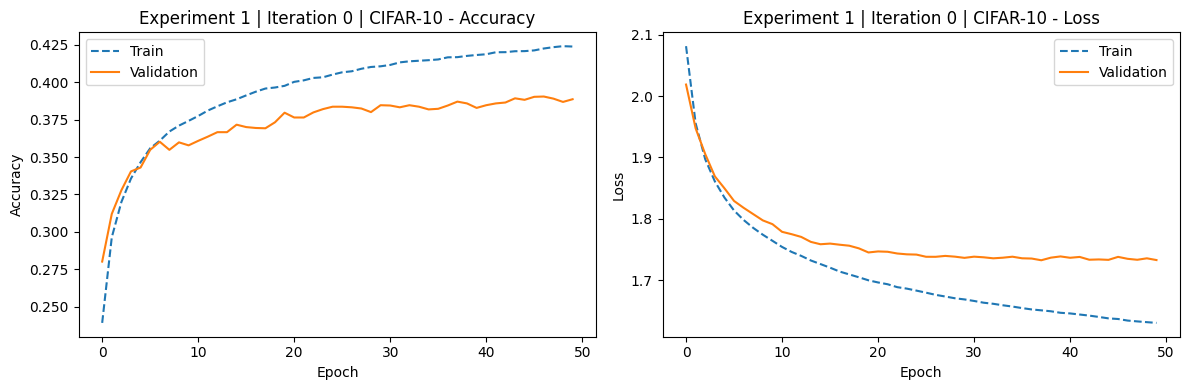

  Train loss      : 1.6304
  Validation loss : 1.7328
  Train accuracy  : 0.4238
  Validation acc  : 0.3886
  Generalization gap (val - train loss): 0.1023
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8567 - loss: 0.5037 - val_accuracy: 0.9345 - val_loss: 0.2288
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9324 - loss: 0.2315 - val_accuracy: 0.9473 - val_loss: 0.1838
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9453 - loss: 0.1831 - val_accuracy: 0.9522 - val_loss: 0.1598
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9537 - loss: 0.1536 - val_accuracy: 0.9552 - val_loss: 0.1449
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9603 - loss: 0.1324 - val_accuracy: 0.9600 - val_loss: 0.1340
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9655 - loss: 0.1162 - val_accuracy: 0.9622 - val_loss: 0.1277
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9688 - loss: 0.1037 - val_accuracy: 0.9637 - val_loss: 0.1208
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9723 - loss: 0.0934 - val_accuracy: 0.9662 - val_

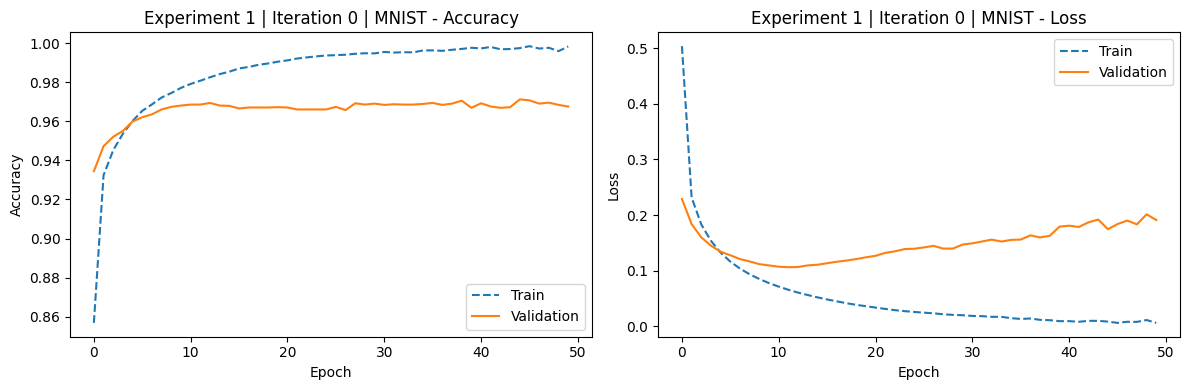

  Train loss      : 0.0061
  Validation loss : 0.1910
  Train accuracy  : 0.9985
  Validation acc  : 0.9677
  Generalization gap (val - train loss): 0.1850
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2328 - loss: 2.0972 - val_accuracy: 0.2662 - val_loss: 2.0332
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2923 - loss: 1.9741 - val_accuracy: 0.2888 - val_loss: 1.9755
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3166 - loss: 1.9160 - val_accuracy: 0.3090 - val_loss: 1.9404
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3307 - loss: 1.8767 - val_accuracy: 0.3224 - val_loss: 1.9090
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3408 - loss: 1.8495 - val_accuracy: 0.3374 - val_loss: 1.8749
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3472 - loss: 1.8302 - val_accuracy: 0.3438 - val_loss: 1.8616
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3537 - loss: 1.8135 - val_accuracy: 0.3484 - val_loss: 1.8430
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3597 - loss: 1.7998 - val_accuracy: 0.3518 - val_

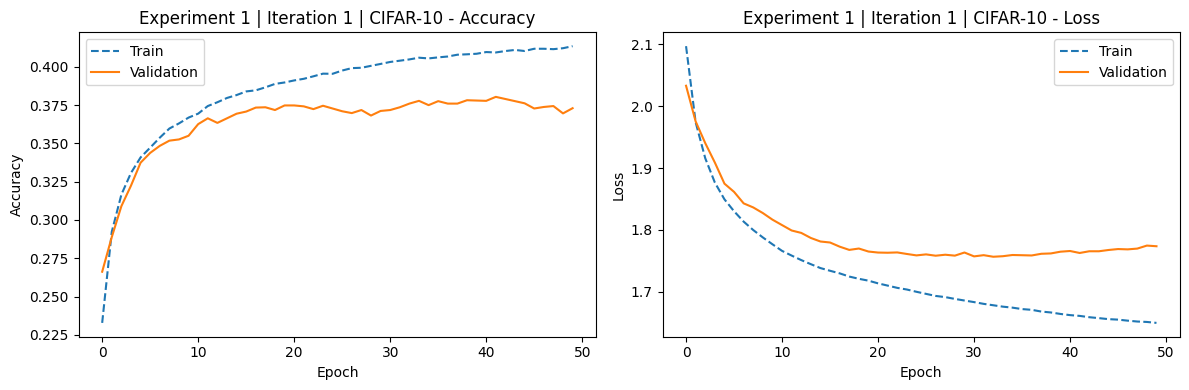

  Train loss      : 1.6497
  Validation loss : 1.7736
  Train accuracy  : 0.4135
  Validation acc  : 0.3730
  Generalization gap (val - train loss): 0.1240
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8521 - loss: 0.5139 - val_accuracy: 0.9402 - val_loss: 0.2095
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9372 - loss: 0.2143 - val_accuracy: 0.9547 - val_loss: 0.1593
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9501 - loss: 0.1687 - val_accuracy: 0.9605 - val_loss: 0.1373
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9575 - loss: 0.1432 - val_accuracy: 0.9655 - val_loss: 0.1227
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9637 - loss: 0.1245 - val_accuracy: 0.9672 - val_loss: 0.1144
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9674 - loss: 0.1104 - val_accuracy: 0.9680 - val_loss: 0.1088
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9711 - loss: 0.0990 - val_accuracy: 0.9693 - val_loss: 0.1065
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9743 - loss: 0.0896 - val_accuracy: 0.9698 - val_

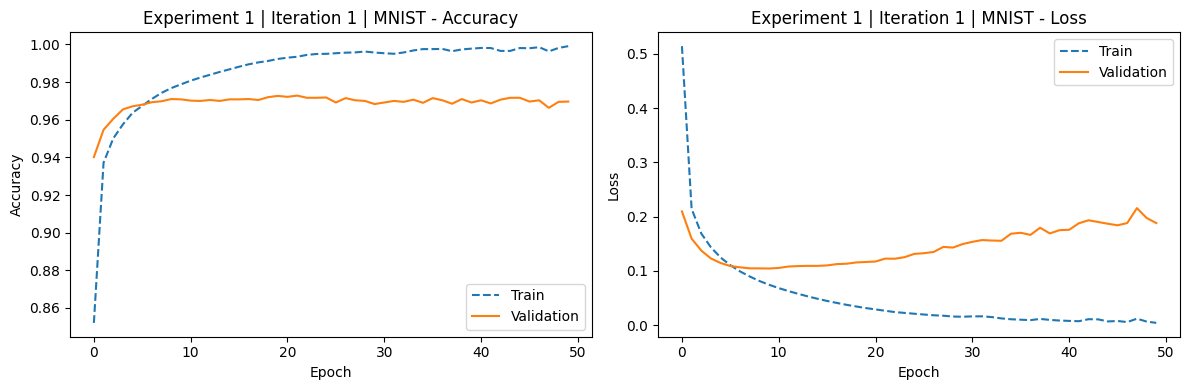

  Train loss      : 0.0041
  Validation loss : 0.1880
  Train accuracy  : 0.9991
  Validation acc  : 0.9697
  Generalization gap (val - train loss): 0.1839
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2324 - loss: 2.0897 - val_accuracy: 0.2672 - val_loss: 2.0309
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2938 - loss: 1.9614 - val_accuracy: 0.2938 - val_loss: 1.9683
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3201 - loss: 1.9042 - val_accuracy: 0.3224 - val_loss: 1.9147
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3328 - loss: 1.8718 - val_accuracy: 0.3366 - val_loss: 1.8807
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3431 - loss: 1.8478 - val_accuracy: 0.3432 - val_loss: 1.8560
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3518 - loss: 1.8279 - val_accuracy: 0.3494 - val_loss: 1.8374
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3580 - loss: 1.8108 - val_accuracy: 0.3564 - val_loss: 1.8273
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3638 - loss: 1.7975 - val_accuracy: 0.3568 - val_

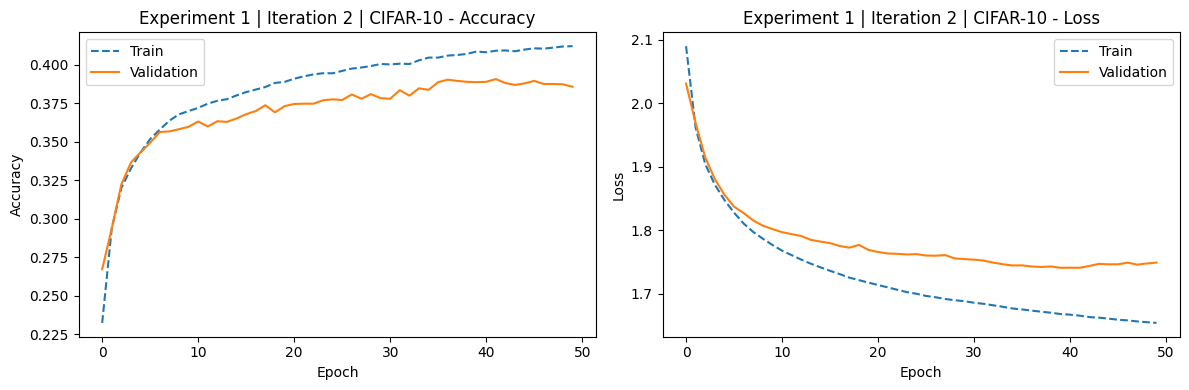

  Train loss      : 1.6545
  Validation loss : 1.7494
  Train accuracy  : 0.4122
  Validation acc  : 0.3858
  Generalization gap (val - train loss): 0.0948
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8512 - loss: 0.5171 - val_accuracy: 0.9398 - val_loss: 0.2128
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9363 - loss: 0.2178 - val_accuracy: 0.9525 - val_loss: 0.1658
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9495 - loss: 0.1737 - val_accuracy: 0.9600 - val_loss: 0.1412
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9570 - loss: 0.1472 - val_accuracy: 0.9638 - val_loss: 0.1287
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9621 - loss: 0.1280 - val_accuracy: 0.9647 - val_loss: 0.1208
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9662 - loss: 0.1131 - val_accuracy: 0.9670 - val_loss: 0.1165
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9699 - loss: 0.1010 - val_accuracy: 0.9698 - val_loss: 0.1109
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9731 - loss: 0.0912 - val_accuracy: 0.9713 - val_

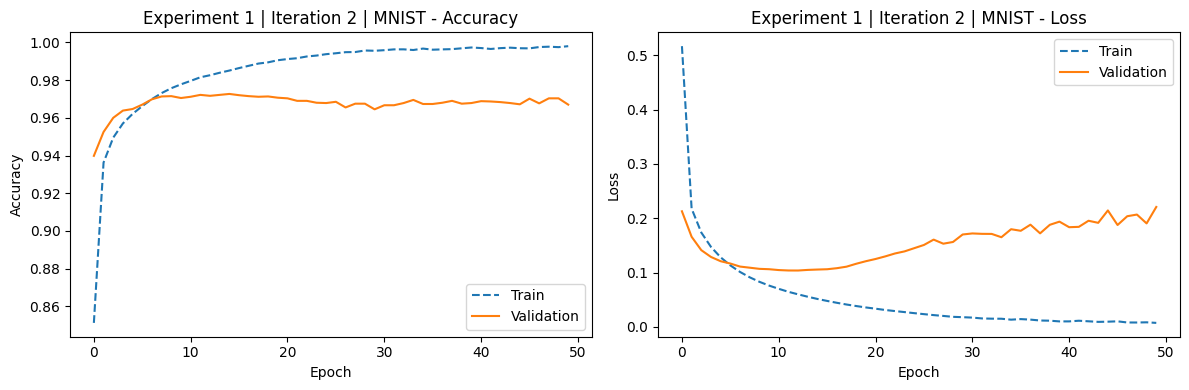

  Train loss      : 0.0072
  Validation loss : 0.2208
  Train accuracy  : 0.9980
  Validation acc  : 0.9670
  Generalization gap (val - train loss): 0.2136


In [12]:
# Training and evaluating the model

for i in range(3):
    run_experiment(
        f"Experiment 1 | Iteration {i} | CIFAR-10",
        cifar_x_train_gray_flat_df, 
        cifar_y_train_cat_df, 
        cifar_x_test_gray_flat_df, 
        cifar_y_test_cat_df
    )

    run_experiment(
        f"Experiment 1 | Iteration {i} | MNIST",
        mnist_x_train_gray_flat_df, 
        mnist_y_train_cat_df, 
        mnist_x_test_gray_flat_df, 
        mnist_y_test_cat_df
    )

# Experimento 2 - Sem dropout e com early stop

Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2234 - loss: 2.1120 - val_accuracy: 0.2584 - val_loss: 2.0440
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2844 - loss: 1.9863 - val_accuracy: 0.3020 - val_loss: 1.9721
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3108 - loss: 1.9249 - val_accuracy: 0.3138 - val_loss: 1.9403
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3245 - loss: 1.8883 - val_accuracy: 0.3212 - val_loss: 1.9118
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3315 - loss: 1.8651 - val_accuracy: 0.3210 - val_loss: 1.8958
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3371 - loss: 1.8498 - val_accuracy: 0.3288 - val_loss: 1.8843
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3417 - loss: 1.8381 - val_accuracy: 0.3364 - val_loss: 1.8690
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3472 - loss: 1.8276 - val_accuracy: 0.3370 - val_

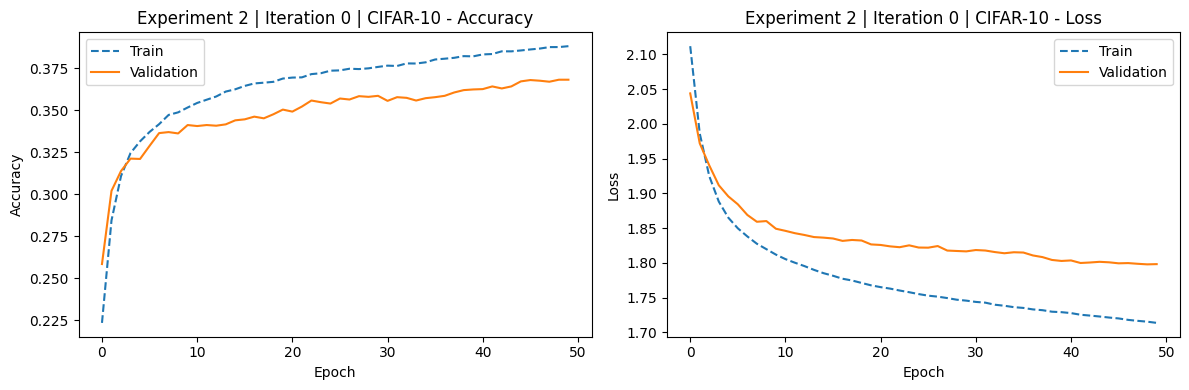

  Train loss      : 1.7136
  Validation loss : 1.7982
  Train accuracy  : 0.3882
  Validation acc  : 0.3682
  Generalization gap (val - train loss): 0.0846
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8547 - loss: 0.4993 - val_accuracy: 0.9425 - val_loss: 0.2040
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9391 - loss: 0.2083 - val_accuracy: 0.9585 - val_loss: 0.1556
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9532 - loss: 0.1620 - val_accuracy: 0.9653 - val_loss: 0.1321
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9611 - loss: 0.1352 - val_accuracy: 0.9698 - val_loss: 0.1212
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9664 - loss: 0.1170 - val_accuracy: 0.9695 - val_loss: 0.1127
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9697 - loss: 0.1040 - val_accuracy: 0.9692 - val_loss: 0.1089
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9732 - loss: 0.0935 - val_accuracy: 0.9707 - val_loss: 0.1063
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9756 - loss: 0.0849 - val_accuracy: 0.9707 - val_

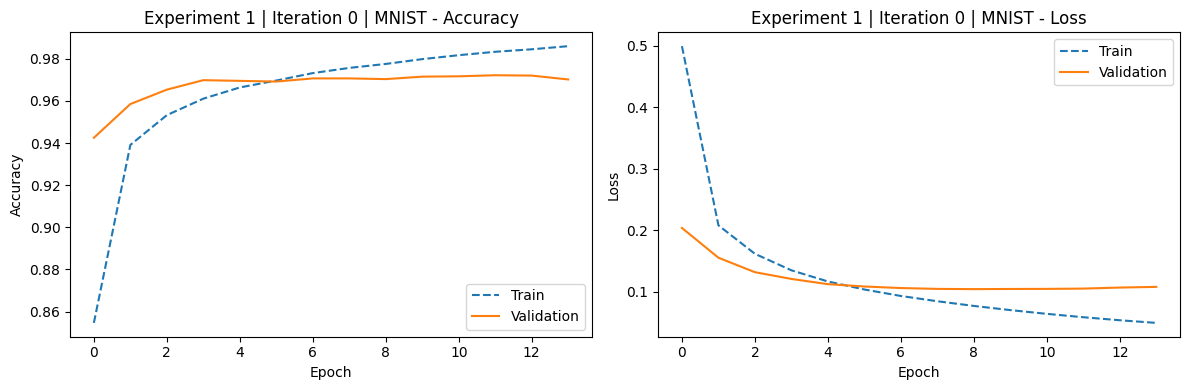

  Train loss      : 0.0497
  Validation loss : 0.1082
  Train accuracy  : 0.9860
  Validation acc  : 0.9702
  Generalization gap (val - train loss): 0.0585
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2380 - loss: 2.0825 - val_accuracy: 0.2736 - val_loss: 2.0305
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2954 - loss: 1.9647 - val_accuracy: 0.3070 - val_loss: 1.9513
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3197 - loss: 1.9051 - val_accuracy: 0.3272 - val_loss: 1.9151
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3324 - loss: 1.8704 - val_accuracy: 0.3374 - val_loss: 1.8886
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3412 - loss: 1.8471 - val_accuracy: 0.3432 - val_loss: 1.8636
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3497 - loss: 1.8271 - val_accuracy: 0.3440 - val_loss: 1.8555
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3556 - loss: 1.8106 - val_accuracy: 0.3452 - val_loss: 1.8504
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3616 - loss: 1.7960 - val_accuracy: 0.3450 - val_

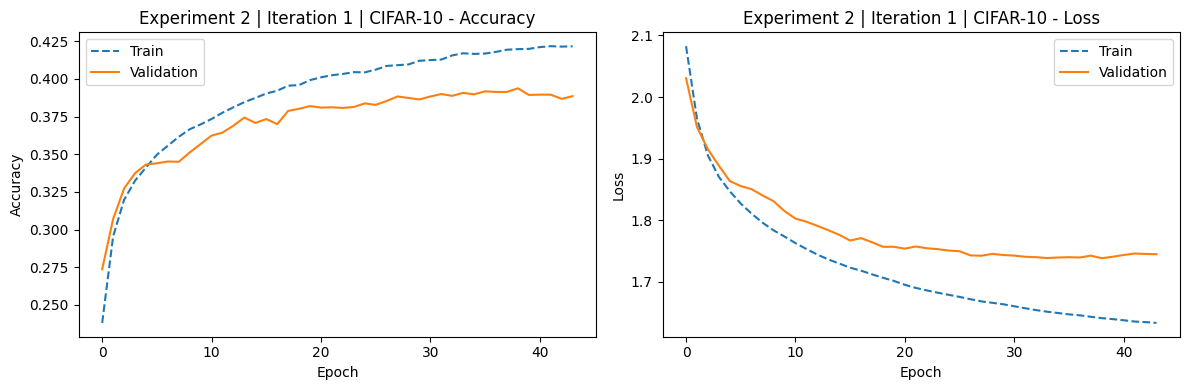

  Train loss      : 1.6335
  Validation loss : 1.7450
  Train accuracy  : 0.4217
  Validation acc  : 0.3886
  Generalization gap (val - train loss): 0.1115
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8609 - loss: 0.5039 - val_accuracy: 0.9425 - val_loss: 0.2120
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9366 - loss: 0.2197 - val_accuracy: 0.9513 - val_loss: 0.1674
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9488 - loss: 0.1755 - val_accuracy: 0.9572 - val_loss: 0.1440
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9568 - loss: 0.1478 - val_accuracy: 0.9605 - val_loss: 0.1285
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9619 - loss: 0.1280 - val_accuracy: 0.9652 - val_loss: 0.1175
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9665 - loss: 0.1132 - val_accuracy: 0.9673 - val_loss: 0.1101
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9699 - loss: 0.1012 - val_accuracy: 0.9678 - val_loss: 0.1055
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9730 - loss: 0.0916 - val_accuracy: 0.9682 - val_

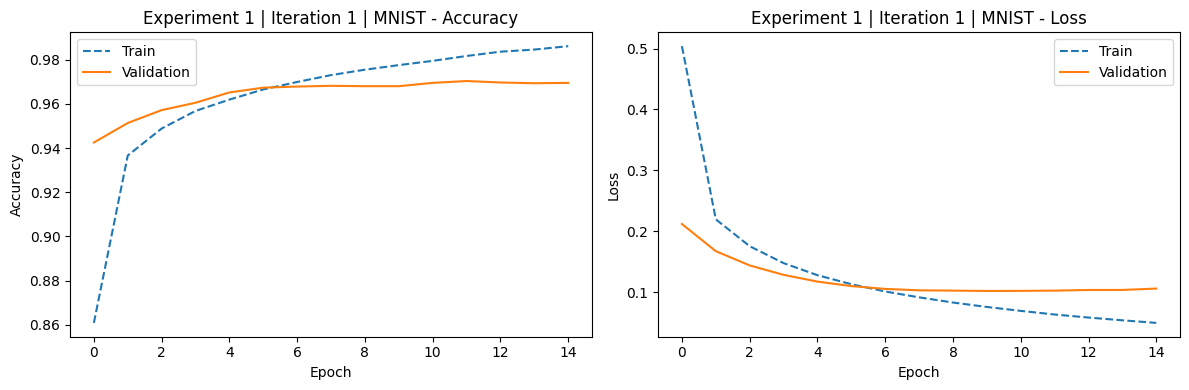

  Train loss      : 0.0497
  Validation loss : 0.1060
  Train accuracy  : 0.9861
  Validation acc  : 0.9695
  Generalization gap (val - train loss): 0.0563
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2272 - loss: 2.1077 - val_accuracy: 0.2682 - val_loss: 2.0521
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2868 - loss: 1.9887 - val_accuracy: 0.3000 - val_loss: 1.9761
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3070 - loss: 1.9327 - val_accuracy: 0.3084 - val_loss: 1.9374
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3187 - loss: 1.9007 - val_accuracy: 0.3220 - val_loss: 1.9066
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3270 - loss: 1.8784 - val_accuracy: 0.3250 - val_loss: 1.8899
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3334 - loss: 1.8623 - val_accuracy: 0.3318 - val_loss: 1.8736
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3380 - loss: 1.8501 - val_accuracy: 0.3310 - val_loss: 1.8638
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3420 - loss: 1.8401 - val_accuracy: 0.3382 - val_

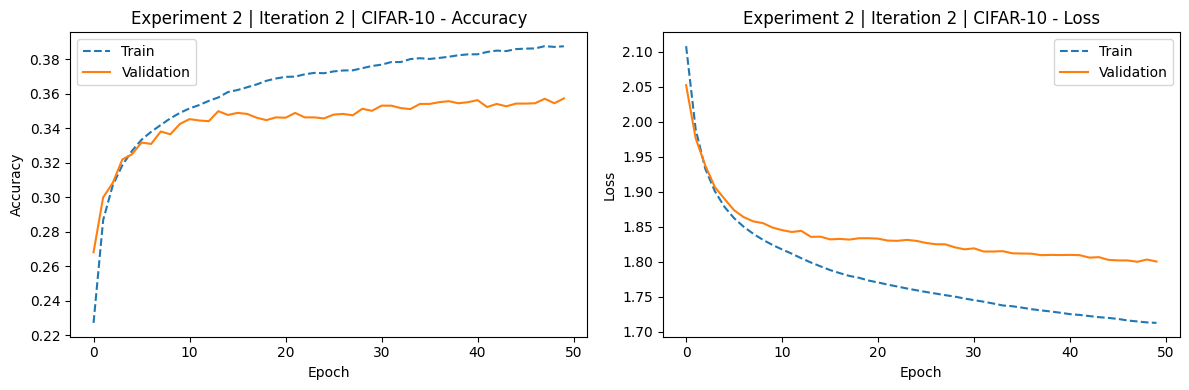

  Train loss      : 1.7130
  Validation loss : 1.8005
  Train accuracy  : 0.3876
  Validation acc  : 0.3574
  Generalization gap (val - train loss): 0.0875
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8682 - loss: 0.4799 - val_accuracy: 0.9403 - val_loss: 0.2066
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9376 - loss: 0.2114 - val_accuracy: 0.9530 - val_loss: 0.1602
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9501 - loss: 0.1689 - val_accuracy: 0.9592 - val_loss: 0.1391
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9578 - loss: 0.1423 - val_accuracy: 0.9620 - val_loss: 0.1279
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9634 - loss: 0.1237 - val_accuracy: 0.9645 - val_loss: 0.1205
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9675 - loss: 0.1091 - val_accuracy: 0.9663 - val_loss: 0.1136
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9709 - loss: 0.0971 - val_accuracy: 0.9678 - val_loss: 0.1076
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9736 - loss: 0.0873 - val_accuracy: 0.9698 - val_

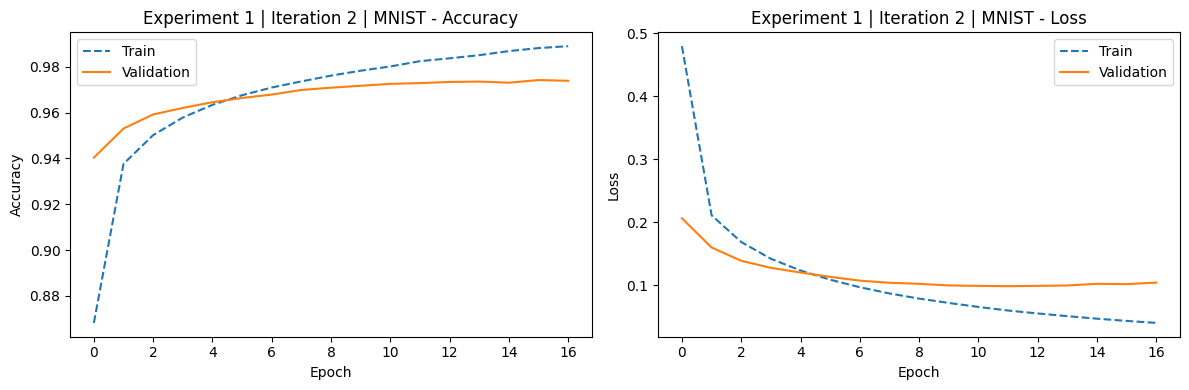

  Train loss      : 0.0405
  Validation loss : 0.1045
  Train accuracy  : 0.9889
  Validation acc  : 0.9738
  Generalization gap (val - train loss): 0.0640


In [13]:
# Training and evaluating the model

for i in range(3):
    run_experiment(
        f"Experiment 2 | Iteration {i} | CIFAR-10",
        cifar_x_train_gray_flat_df, 
        cifar_y_train_cat_df, 
        cifar_x_test_gray_flat_df, 
        cifar_y_test_cat_df,
        early_stopping=True,
        patience=early_stopping_patience
    )

    run_experiment(
        f"Experiment 1 | Iteration {i} | MNIST",
        mnist_x_train_gray_flat_df, 
        mnist_y_train_cat_df, 
        mnist_x_test_gray_flat_df, 
        mnist_y_test_cat_df,
        early_stopping=True,
        patience=early_stopping_patience
    )

# Experimento 3 - Com dropout e sem early stop

Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1761 - loss: 2.1944 - val_accuracy: 0.2448 - val_loss: 2.1007
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2176 - loss: 2.1128 - val_accuracy: 0.2548 - val_loss: 2.0631
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2254 - loss: 2.0882 - val_accuracy: 0.2462 - val_loss: 2.0607
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2307 - loss: 2.0744 - val_accuracy: 0.2694 - val_loss: 2.0337
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2374 - loss: 2.0562 - val_accuracy: 0.2758 - val_loss: 2.0144
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2451 - loss: 2.0387 - val_accuracy: 0.2788 - val_loss: 1.9962
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2479 - loss: 2.0348 - val_accuracy: 0.2754 - val_loss: 2.0051
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2552 - loss: 2.0222 - val_accuracy: 0.2772 - val_

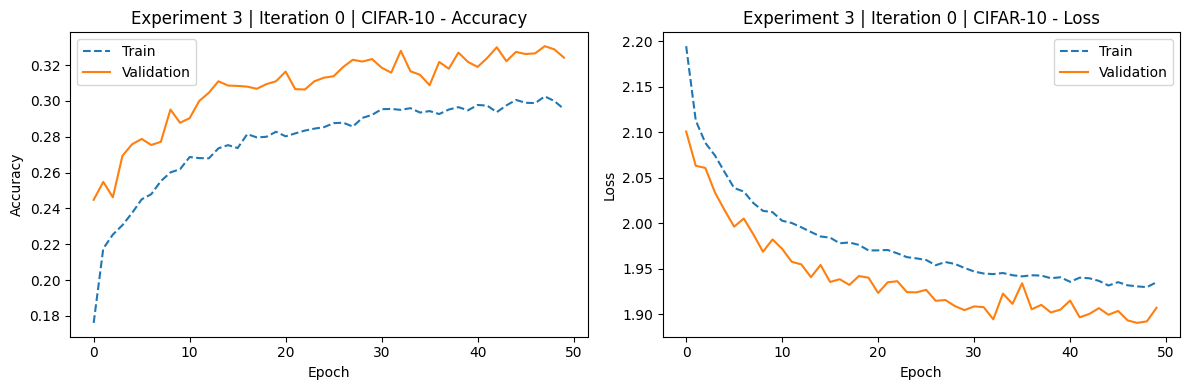

  Train loss      : 1.9352
  Validation loss : 1.9071
  Train accuracy  : 0.2955
  Validation acc  : 0.3242
  Generalization gap (val - train loss): -0.0281
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7700 - loss: 0.7278 - val_accuracy: 0.9352 - val_loss: 0.2277
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8905 - loss: 0.3674 - val_accuracy: 0.9473 - val_loss: 0.1805
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9076 - loss: 0.3089 - val_accuracy: 0.9538 - val_loss: 0.1553
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9181 - loss: 0.2738 - val_accuracy: 0.9587 - val_loss: 0.1392
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9239 - loss: 0.2497 - val_accuracy: 0.9607 - val_loss: 0.1298
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9282 - loss: 0.2359 - val_accuracy: 0.9635 - val_loss: 0.1229
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9321 - loss: 0.2226 - val_accuracy: 0.9642 - val_loss: 0.1205
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9367 - loss: 0.2080 - val_accuracy: 0.9655 - val_

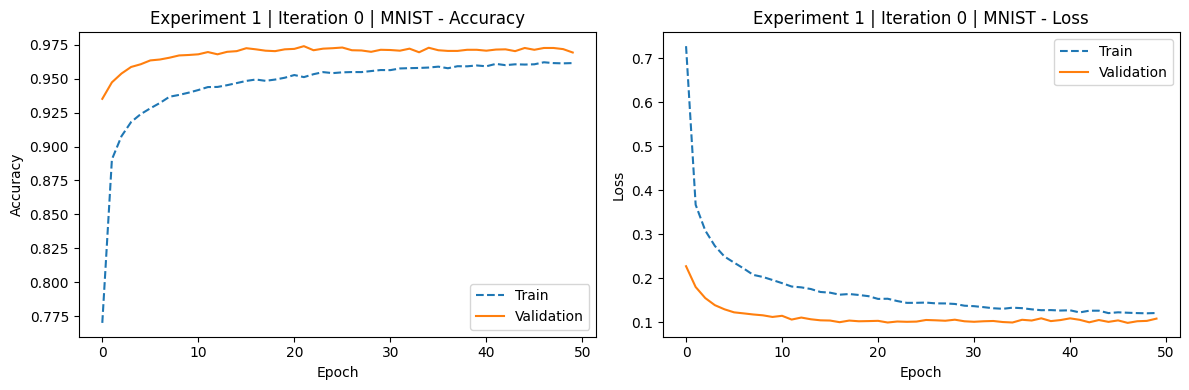

  Train loss      : 0.1214
  Validation loss : 0.1086
  Train accuracy  : 0.9615
  Validation acc  : 0.9693
  Generalization gap (val - train loss): -0.0128
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1791 - loss: 2.1845 - val_accuracy: 0.2244 - val_loss: 2.1112
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2114 - loss: 2.1130 - val_accuracy: 0.2524 - val_loss: 2.0586
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2218 - loss: 2.0871 - val_accuracy: 0.2562 - val_loss: 2.0552
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2322 - loss: 2.0742 - val_accuracy: 0.2608 - val_loss: 2.0531
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2372 - loss: 2.0624 - val_accuracy: 0.2676 - val_loss: 2.0269
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2402 - loss: 2.0548 - val_accuracy: 0.2704 - val_loss: 2.0238
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2444 - loss: 2.0478 - val_accuracy: 0.2734 - val_loss: 2.0256
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2482 - loss: 2.0423 - val_accuracy: 0.2758 - val_

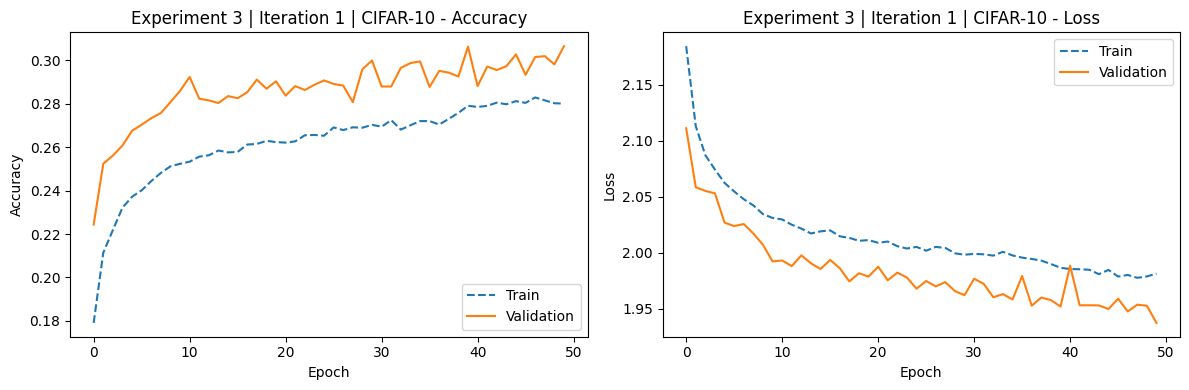

  Train loss      : 1.9814
  Validation loss : 1.9374
  Train accuracy  : 0.2801
  Validation acc  : 0.3066
  Generalization gap (val - train loss): -0.0440
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7771 - loss: 0.7224 - val_accuracy: 0.9408 - val_loss: 0.2195
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8886 - loss: 0.3688 - val_accuracy: 0.9487 - val_loss: 0.1786
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9044 - loss: 0.3128 - val_accuracy: 0.9545 - val_loss: 0.1612
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9169 - loss: 0.2773 - val_accuracy: 0.9607 - val_loss: 0.1435
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9224 - loss: 0.2568 - val_accuracy: 0.9612 - val_loss: 0.1370
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9262 - loss: 0.2424 - val_accuracy: 0.9625 - val_loss: 0.1325
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9294 - loss: 0.2312 - val_accuracy: 0.9635 - val_loss: 0.1263
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9322 - loss: 0.2202 - val_accuracy: 0.9628 - val_

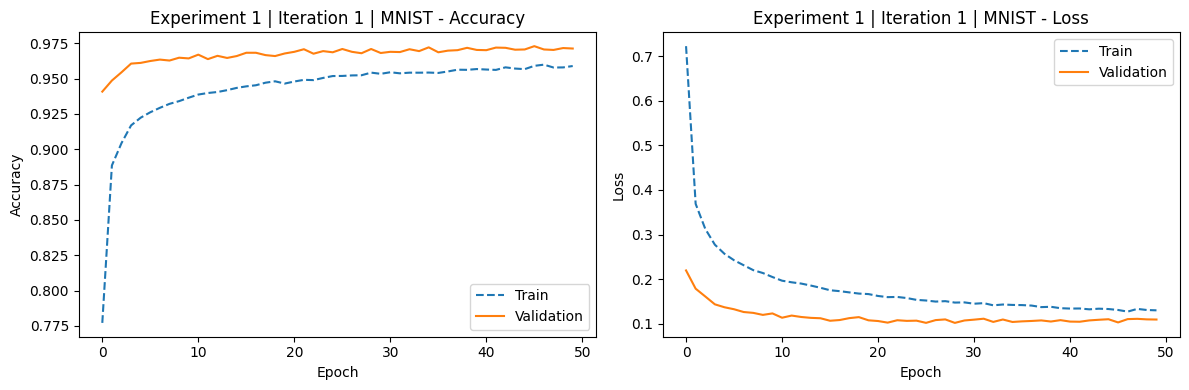

  Train loss      : 0.1301
  Validation loss : 0.1094
  Train accuracy  : 0.9589
  Validation acc  : 0.9713
  Generalization gap (val - train loss): -0.0206
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1637 - loss: 2.2106 - val_accuracy: 0.2384 - val_loss: 2.1136
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2077 - loss: 2.1289 - val_accuracy: 0.2392 - val_loss: 2.0913
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2136 - loss: 2.1070 - val_accuracy: 0.2574 - val_loss: 2.0620
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2216 - loss: 2.0985 - val_accuracy: 0.2504 - val_loss: 2.0677
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2250 - loss: 2.0832 - val_accuracy: 0.2518 - val_loss: 2.0534
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2306 - loss: 2.0731 - val_accuracy: 0.2520 - val_loss: 2.0469
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2340 - loss: 2.0670 - val_accuracy: 0.2498 - val_loss: 2.0434
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2341 - loss: 2.0604 - val_accuracy: 0.2482 - val_

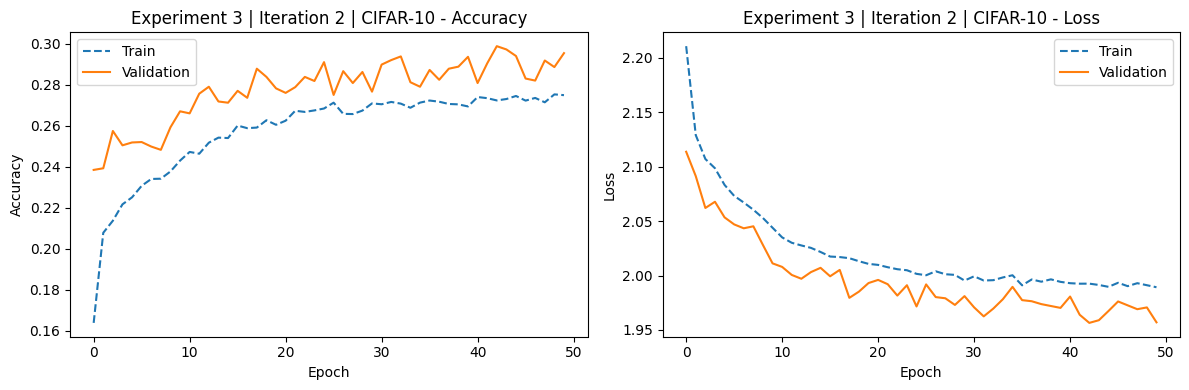

  Train loss      : 1.9892
  Validation loss : 1.9570
  Train accuracy  : 0.2749
  Validation acc  : 0.2954
  Generalization gap (val - train loss): -0.0322
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7739 - loss: 0.7314 - val_accuracy: 0.9358 - val_loss: 0.2233
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8924 - loss: 0.3628 - val_accuracy: 0.9512 - val_loss: 0.1748
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9105 - loss: 0.3032 - val_accuracy: 0.9555 - val_loss: 0.1584
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9165 - loss: 0.2753 - val_accuracy: 0.9597 - val_loss: 0.1414
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9244 - loss: 0.2509 - val_accuracy: 0.9617 - val_loss: 0.1316
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9279 - loss: 0.2383 - val_accuracy: 0.9652 - val_loss: 0.1253
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9305 - loss: 0.2264 - val_accuracy: 0.9663 - val_loss: 0.1197
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9342 - loss: 0.2147 - val_accuracy: 0.9655 - val_

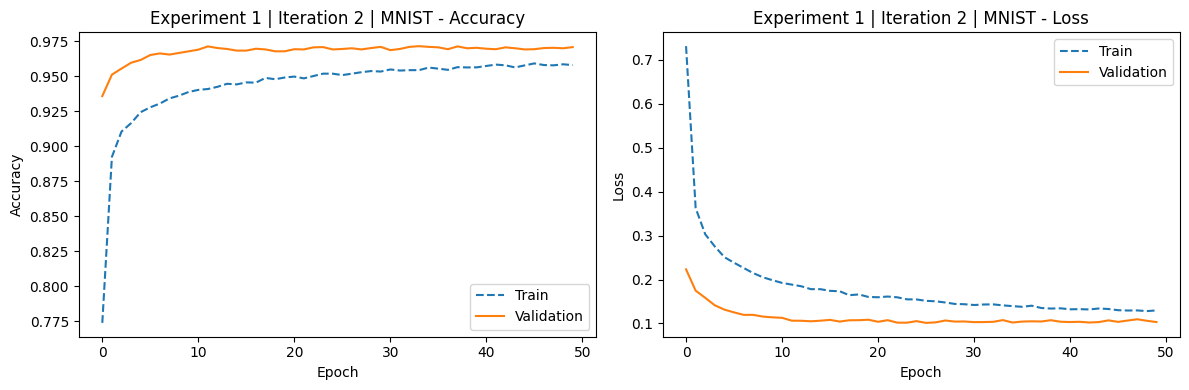

  Train loss      : 0.1298
  Validation loss : 0.1033
  Train accuracy  : 0.9580
  Validation acc  : 0.9708
  Generalization gap (val - train loss): -0.0265


In [14]:
# Training and evaluating the model

for i in range(3):
    run_experiment(
        f"Experiment 3 | Iteration {i} | CIFAR-10",
        cifar_x_train_gray_flat_df, 
        cifar_y_train_cat_df, 
        cifar_x_test_gray_flat_df, 
        cifar_y_test_cat_df,
        dropout_rate=dropout_rate
    )

    run_experiment(
        f"Experiment 1 | Iteration {i} | MNIST",
        mnist_x_train_gray_flat_df, 
        mnist_y_train_cat_df, 
        mnist_x_test_gray_flat_df, 
        mnist_y_test_cat_df,
        dropout_rate=dropout_rate
    )

# Experimento 4 - Com dropout e com early stop

Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1892 - loss: 2.1699 - val_accuracy: 0.2268 - val_loss: 2.0959
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2307 - loss: 2.0871 - val_accuracy: 0.2922 - val_loss: 2.0308
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2525 - loss: 2.0468 - val_accuracy: 0.3006 - val_loss: 1.9788
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2605 - loss: 2.0245 - val_accuracy: 0.2996 - val_loss: 1.9684
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2697 - loss: 2.0059 - val_accuracy: 0.3040 - val_loss: 1.9558
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2732 - loss: 1.9941 - val_accuracy: 0.3166 - val_loss: 1.9374
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2750 - loss: 1.9889 - val_accuracy: 0.3112 - val_loss: 1.9398
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2758 - loss: 1.9829 - val_accuracy: 0.2992 - val_

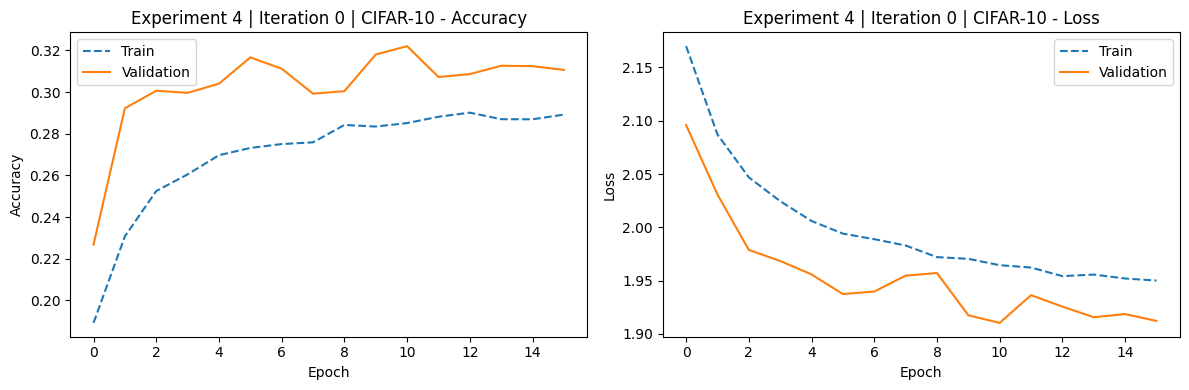

  Train loss      : 1.9500
  Validation loss : 1.9122
  Train accuracy  : 0.2892
  Validation acc  : 0.3106
  Generalization gap (val - train loss): -0.0379
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7644 - loss: 0.7580 - val_accuracy: 0.9347 - val_loss: 0.2336
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8843 - loss: 0.3837 - val_accuracy: 0.9480 - val_loss: 0.1805
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9046 - loss: 0.3160 - val_accuracy: 0.9548 - val_loss: 0.1550
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9153 - loss: 0.2769 - val_accuracy: 0.9628 - val_loss: 0.1344
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9204 - loss: 0.2618 - val_accuracy: 0.9638 - val_loss: 0.1232
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9244 - loss: 0.2417 - val_accuracy: 0.9650 - val_loss: 0.1189
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9306 - loss: 0.2267 - val_accuracy: 0.9643 - val_loss: 0.1154
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9347 - loss: 0.2134 - val_accuracy: 0.9682 - val_

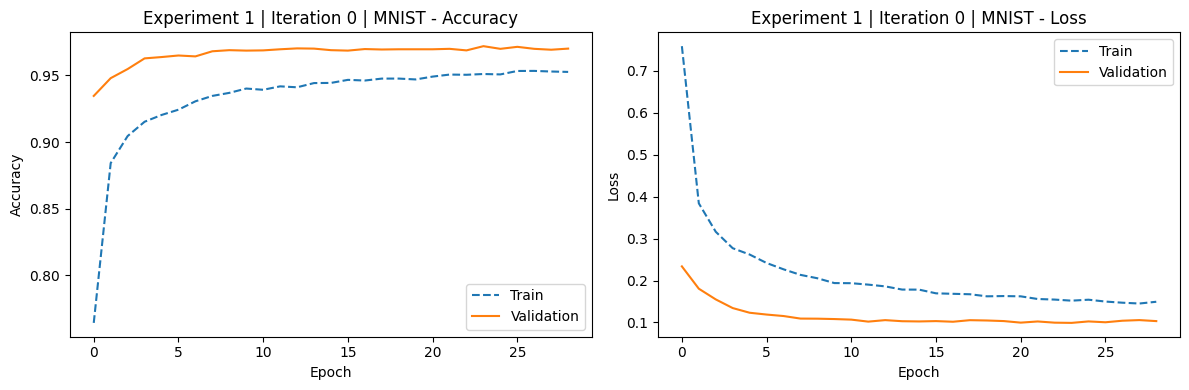

  Train loss      : 0.1494
  Validation loss : 0.1033
  Train accuracy  : 0.9527
  Validation acc  : 0.9702
  Generalization gap (val - train loss): -0.0461
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1561 - loss: 2.2395 - val_accuracy: 0.1900 - val_loss: 2.1575
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1860 - loss: 2.1766 - val_accuracy: 0.1982 - val_loss: 2.1419
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1877 - loss: 2.1637 - val_accuracy: 0.2094 - val_loss: 2.1275
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1959 - loss: 2.1495 - val_accuracy: 0.2204 - val_loss: 2.1241
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2036 - loss: 2.1389 - val_accuracy: 0.2286 - val_loss: 2.1136
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2128 - loss: 2.1280 - val_accuracy: 0.2412 - val_loss: 2.1061
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2198 - loss: 2.1198 - val_accuracy: 0.2360 - val_loss: 2.0998
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2229 - loss: 2.1093 - val_accuracy: 0.2542 - val_

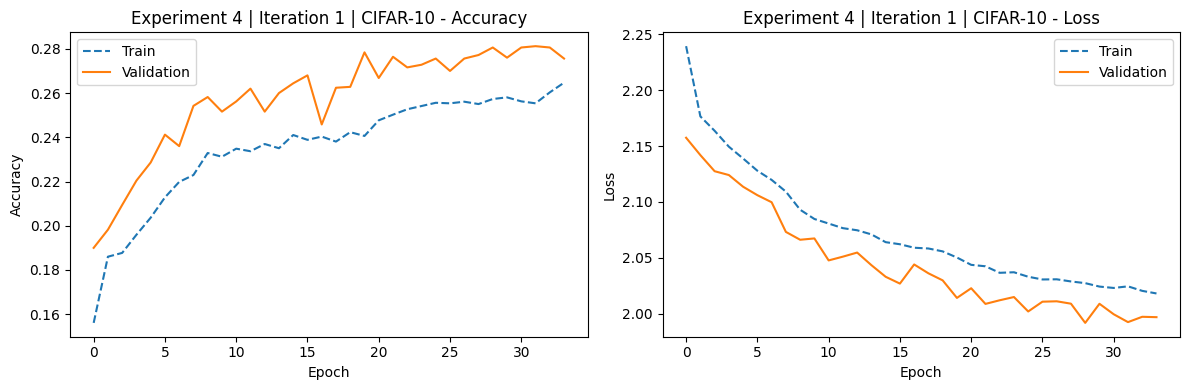

  Train loss      : 2.0181
  Validation loss : 1.9969
  Train accuracy  : 0.2647
  Validation acc  : 0.2756
  Generalization gap (val - train loss): -0.0212
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7875 - loss: 0.6880 - val_accuracy: 0.9398 - val_loss: 0.2142
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8965 - loss: 0.3504 - val_accuracy: 0.9542 - val_loss: 0.1632
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9125 - loss: 0.2933 - val_accuracy: 0.9598 - val_loss: 0.1422
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9227 - loss: 0.2581 - val_accuracy: 0.9638 - val_loss: 0.1294
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9267 - loss: 0.2425 - val_accuracy: 0.9627 - val_loss: 0.1247
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9313 - loss: 0.2275 - val_accuracy: 0.9670 - val_loss: 0.1197
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9336 - loss: 0.2155 - val_accuracy: 0.9662 - val_loss: 0.1189
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9386 - loss: 0.2021 - val_accuracy: 0.9652 - val_

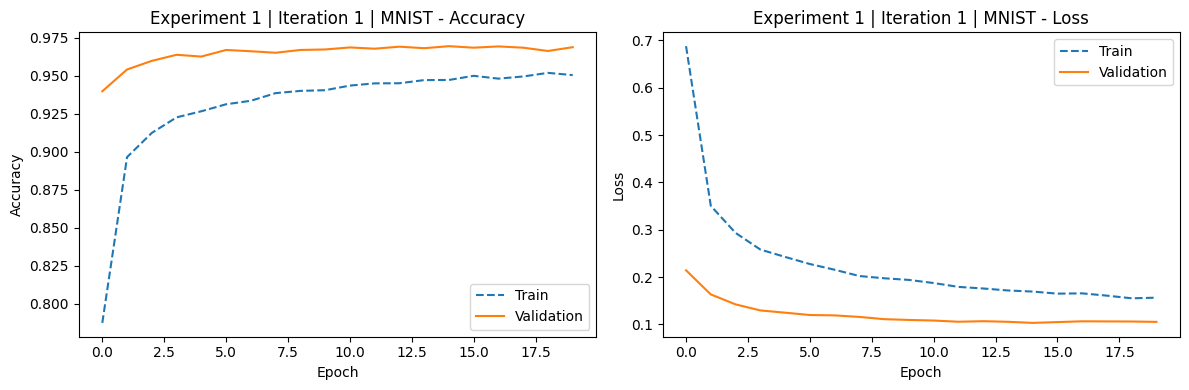

  Train loss      : 0.1564
  Validation loss : 0.1052
  Train accuracy  : 0.9505
  Validation acc  : 0.9688
  Generalization gap (val - train loss): -0.0512
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1875 - loss: 2.1701 - val_accuracy: 0.2584 - val_loss: 2.0807
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2280 - loss: 2.0881 - val_accuracy: 0.2706 - val_loss: 2.0320
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2423 - loss: 2.0631 - val_accuracy: 0.2800 - val_loss: 2.0076
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2504 - loss: 2.0453 - val_accuracy: 0.2730 - val_loss: 2.0109
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2507 - loss: 2.0325 - val_accuracy: 0.2818 - val_loss: 2.0066
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2574 - loss: 2.0224 - val_accuracy: 0.2884 - val_loss: 1.9792
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2605 - loss: 2.0169 - val_accuracy: 0.2920 - val_loss: 1.9808
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2637 - loss: 2.0076 - val_accuracy: 0.3026 - val_

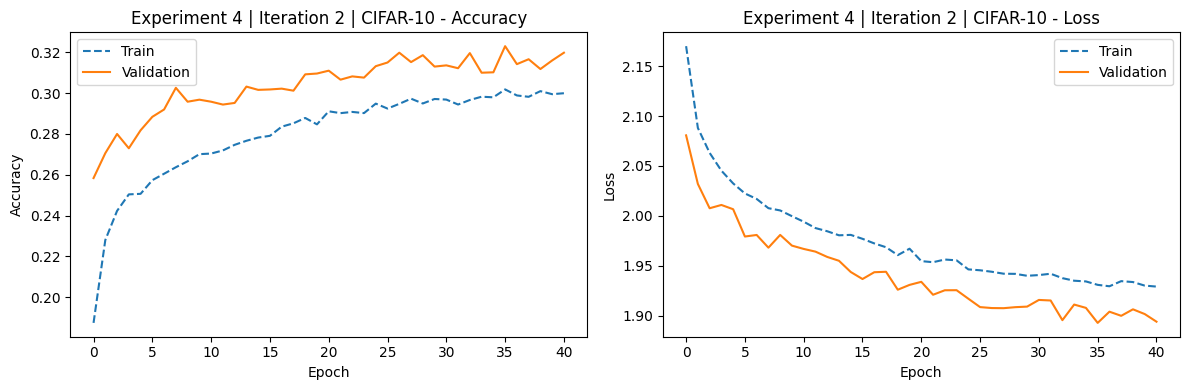

  Train loss      : 1.9290
  Validation loss : 1.8938
  Train accuracy  : 0.3000
  Validation acc  : 0.3198
  Generalization gap (val - train loss): -0.0352
Epoch 1/50


/media/Shared/Projects/UNIVASF/CIFAR10/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7695 - loss: 0.7286 - val_accuracy: 0.9343 - val_loss: 0.2255
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8894 - loss: 0.3734 - val_accuracy: 0.9467 - val_loss: 0.1779
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9049 - loss: 0.3183 - val_accuracy: 0.9578 - val_loss: 0.1487
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9149 - loss: 0.2852 - val_accuracy: 0.9623 - val_loss: 0.1339
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9221 - loss: 0.2572 - val_accuracy: 0.9647 - val_loss: 0.1248
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9267 - loss: 0.2412 - val_accuracy: 0.9648 - val_loss: 0.1213
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9295 - loss: 0.2295 - val_accuracy: 0.9680 - val_loss: 0.1137
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9336 - loss: 0.2174 - val_accuracy: 0.9688 - val_

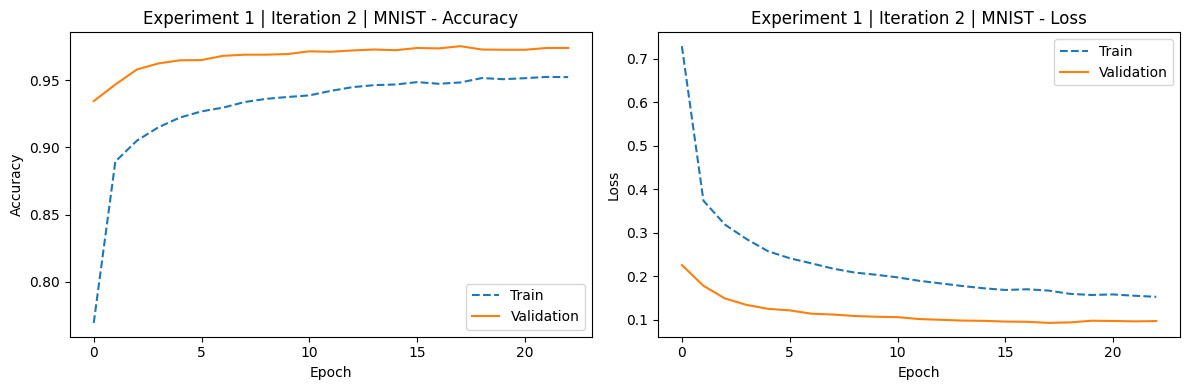

  Train loss      : 0.1525
  Validation loss : 0.0967
  Train accuracy  : 0.9521
  Validation acc  : 0.9738
  Generalization gap (val - train loss): -0.0558


In [15]:
# Training and evaluating the model

for i in range(3):
    run_experiment(
        f"Experiment 4 | Iteration {i} | CIFAR-10",
        cifar_x_train_gray_flat_df, 
        cifar_y_train_cat_df, 
        cifar_x_test_gray_flat_df, 
        cifar_y_test_cat_df,
        dropout_rate=dropout_rate,
        early_stopping=True,
        patience=early_stopping_patience
    )

    run_experiment(
        f"Experiment 1 | Iteration {i} | MNIST",
        mnist_x_train_gray_flat_df, 
        mnist_y_train_cat_df, 
        mnist_x_test_gray_flat_df, 
        mnist_y_test_cat_df,
        dropout_rate=dropout_rate,
        early_stopping=True,
        patience=early_stopping_patience
    )